# Superdense Coding
<hr></hr>

Just like quantum teleportation, [superdense coding](https://en.wikipedia.org/wiki/Superdense_coding) is a quantum communication protocol that exploits the phenomenon of entanglement. In some sense, it can be thought as being complementary to teleportation. The protocol enables the transmission of **two classical bits** of information by encoding them into **a single qubit**. In this way, it is essentially the reverse of teleportation, where the state of **one qubit** is transmitted using **two classical bits**. The caveat, however, is that, just like in teleportation, superdense coding requires the sender and receiver to share an additional pair of entangled qubits, which must be distributed ahead of time.

Superdense coding is claimed to have been first proposed by [Charles Bennett](https://en.wikipedia.org/wiki/Charles_H._Bennett_(physicist)) and [Stephen Wiesner](https://en.wikipedia.org/wiki/Stephen_Wiesner) in 1970 (see [handwritten note](https://www.scottaaronson.com/wiesnernotes1970.jpg) from Bennet), but the results were not formally published until 1992 [[Bennett92](https://journals.aps.org/prl/pdf/10.1103/PhysRevLett.69.2881?casa_token=5mrJEbAGfXwAAAAA%3A5ffd90XeX1vud-ZCCFx9XQquMnmWVL4wymI8mkmPltofBKdNmQcONTLTcHzvmVe_KwNolnlDX2Ol2w)].

## 1. Protocol Description

Similar to what we described in the chapter for [quantum teleportation](https://learnquantum.io/chapters/03_quantum_protocols/03_02_teleportation.html), superdense coding relies on Alice and Bob first sharing an entangled state such as:

$$ |\Phi^+\rangle = \frac{1}{\sqrt{2}} \big(|0\rangle_A|0\rangle_B + |1\rangle_A|1\rangle_B \big),$$

where the subscripts $A$ and $B$ are used to denote Alice’s and Bob’s qubits, respectively. A way to accomplish this is by, for example, having Alice prepare $|\Phi^+\rangle$ on a quantum computer, and then “sending” Bob one of the qubits via a quantum link.

After the entangled qubit is shared with Bob, Alice will **encode** two bits of classical information on her entangled qubit, and send that one to Bob as well. This means that their quantum link must be capable of transmitting that second qubit. 

<img src="images/03_03_01_superdense_transmit.png" align = "center" width="675"/>

However, unlike quantum teleportation, Alice and Bob do not need to establish a classical channel of information.

To understand the details of how this works, we can use a circuit diagram and analyze the evolution of the shared quantum state each step of the way:

<img src="images/03_03_02_superdense_circuit.png" align = "center" width="850"/>

0. Alice starts by initializing her qubits in the all-zeros state: $|0 0 \rangle_A.$

1. She then prepares the $|\Phi^+\rangle$ Bell state:

$$ 
\begin{aligned}
|\psi\rangle_1 &= |\Phi^+\rangle_A
\\
\\
|\psi\rangle_1 &= \frac{1}{\sqrt{2}} \big(|0\rangle_A|0\rangle_A + |1\rangle_A|1\rangle_A \big). 
\end{aligned}$$

Alice then proceeds to send one of the entangled qubits to Bob. Doing this doesn't change the state itself; we just relabel the subscripts to indicate who has which qubit:

$$ |\psi\rangle_1 = \frac{1}{\sqrt{2}} \big(|0\rangle_A|0\rangle_B + |1\rangle_A|1\rangle_B \big). $$

2. With the entangled pair of qubits in place, Alice can then encode two classical bits of information $(j,i),$ which can take values of $(0,0), (0,1), (1,0), (1,1)$. She does this by applying an $X$ gate condition on the value of $i,$ and a $Z$ gate condition on the value of $j.$ The overall system state is then given by:

$$ 
\begin{aligned}
|\psi\rangle_2 &= (Z^j \otimes I) (X^i \otimes I) |\psi\rangle_1
\\
\\
|\psi\rangle_2 &= \frac{1}{\sqrt{2}} \left[\big(Z^j\, X^i \big)|0 \rangle_A \otimes |0\rangle_B + \big(Z^j\, X^i \big)|1 \rangle_A \otimes |1\rangle_B \right].
\end{aligned}
$$

Granted that $X^0 = Z^0 = I,$ we then have four possible states that depend on the value of the bits Alice encoded:

$$
\begin{split} |\psi \rangle_2 = 
\begin{cases}
\frac{1}{\sqrt{2}} \left[\big(I\, I \big)|0 \rangle_A \otimes |0\rangle_B + \big(I\, I \big)|1 \rangle_A \otimes |1\rangle_B \right] & \text{if } (j,i) = (0,0)
\\
\\
\frac{1}{\sqrt{2}} \left[\big(I\, X \big)|0 \rangle_A \otimes |0\rangle_B + \big(I\, X \big)|1 \rangle_A \otimes |1\rangle_B \right] & \text{if } (j,i) = (0,1)
\\
\\
\frac{1}{\sqrt{2}} \left[\big(Z\, I \big)|0 \rangle_A \otimes |0\rangle_B + \big(Z\, I \big)|1 \rangle_A \otimes |1\rangle_B \right] & \text{if } (j,i) = (1,0)
\\
\\
\frac{1}{\sqrt{2}} \left[\big(Z\, X \big)|0 \rangle_A \otimes |0\rangle_B + \big(Z\, X \big)|1 \rangle_A \otimes |1\rangle_B \right] & \text{if } (j,i) = (1,1).
\end{cases}
\end{split}
$$

Applying the unitary operations to the qubit held by Alice then yields the following four possible states:

$$
\begin{split} |\psi \rangle_2 = 
\begin{cases}
\frac{1}{\sqrt{2}} \big(|0 \rangle_A \otimes |0\rangle_B + |1 \rangle_A \otimes |1\rangle_B \big) & \text{if } (j,i) = (0,0)
\\
\\
\frac{1}{\sqrt{2}} \big(|1 \rangle_A \otimes |0\rangle_B + |0 \rangle_A \otimes |1\rangle_B \big) & \text{if } (j,i) = (0,1)
\\
\\
\frac{1}{\sqrt{2}} \big(|0 \rangle_A \otimes |0\rangle_B - |1 \rangle_A \otimes |1\rangle_B \big)& \text{if } (j,i) = (1,0)
\\
\\
\frac{-1}{\sqrt{2}} \big(|1 \rangle_A \otimes |0\rangle_B - |0 \rangle_A \otimes |1\rangle_B \big)& \text{if } (j,i) = (1,1).
\end{cases}
\end{split}
$$

As can be seen, these are the four [Bell states](https://en.wikipedia.org/wiki/Bell_state) we've discussed before:

$$
\begin{split} |\psi \rangle_2 = 
\begin{cases}
|\Phi^+\rangle & \text{if } (j,i) = (0,0)
\\
\\
|\Psi^+\rangle & \text{if } (j,i) = (0,1)
\\
\\
|\Phi^-\rangle & \text{if } (j,i) = (1,0)
\\
\\
|\Psi^-\rangle & \text{if } (j,i) = (1,1).
\end{cases}
\end{split}
$$

Next, Alice proceeds to transmit to Bob her qubit, so now Bob has in his possession one of four possible two-qubit states shown above, which depends on the two-bit classical value Alice encoded on her qubit.

3. Lastly, Bob applies a $CX$ gate followed by an $H$ gate, which converts the state from the Bell basis into the computational basis:

$$ |\psi\rangle_3 = (H \otimes I) \, CX |\psi\rangle_2, $$

resulting in the following four possible outputs:

$$
\begin{split} |\psi \rangle_2 = 
\begin{cases}
|00\rangle & \text{if } (j,i) = (0,0)
\\
\\
|01\rangle & \text{if } (j,i) = (0,1)
\\
\\
|10\rangle & \text{if } (j,i) = (1,0)
\\
\\
|11\rangle & \text{if } (j,i) = (1,1).
\end{cases}
\end{split}
$$

If Bob then performs a measurement on his qubits, he will get with $100 \%$ probability the exact same bits that Alice had encoded.

Let's run this circuit in qiskit to verify that this is in fact the case.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator

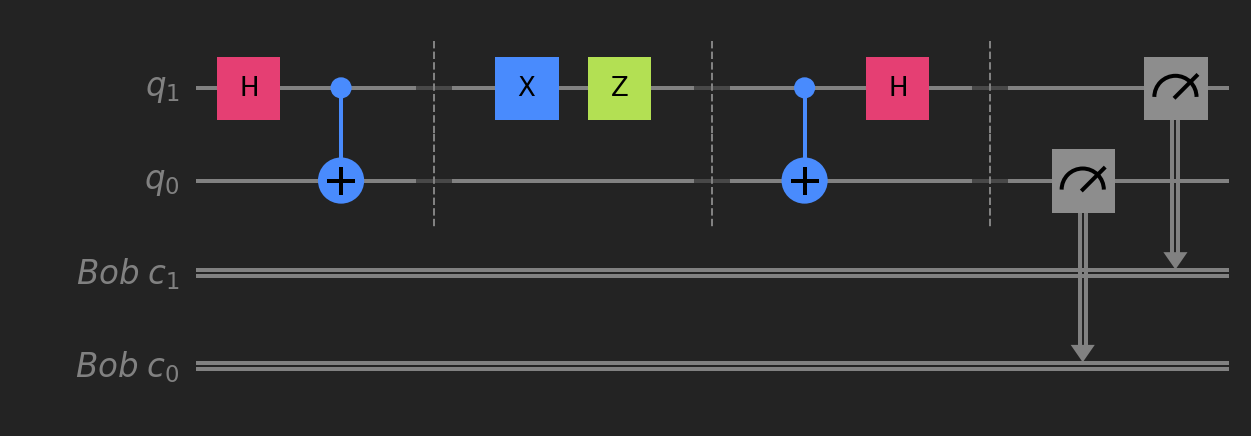

In [2]:
# Alice selects qubits to encode (picked at random for demo purposes)
alice_bits = np.random.randint(2,size=2)

qr = QuantumRegister(2,name="q")
cr = ClassicalRegister(2, name="Bob c")

qc = QuantumCircuit(qr,cr)

# Alice and Bob share entangled Bell state
qc.h(qr[1])
qc.cx(qr[1],qr[0])
qc.barrier()

# Alice encodes classical bits on her qubit
if alice_bits[1] == 1: qc.x(1)
if alice_bits[0] == 1: qc.z(1)
qc.barrier()

# Bob changes from Bell to Computational basis
qc.cx(qr[1],qr[0])
qc.h(qr[1])
qc.barrier()

# Alice measures her qubits
qc.measure(qr,cr)
display(qc.draw(cregbundle=False))

In [3]:
# run simulation
simulator = AerSimulator()
qc_t = transpile(qc, simulator)

bob_bits = simulator.run(qc_t, shots=1, memory=True).result().get_memory()[0]

print(f'Alice enconded bits ({alice_bits[1]},{alice_bits[0]})')
print(f'Bob recovered bits ({bob_bits[1]},{bob_bits[0]})')

Alice enconded bits (1,1)
Bob recovered bits (1,1)


## 2. Encoding More Bits

To encode $n$ bits of information, Alice can go from using a $2$-qubit Bell state to an $n$-qubit GHZ state:

$$ |\Omega_n\rangle = \frac{1}{\sqrt{2}}\left(|0\rangle_A^{\otimes (n-1)}\otimes|0\rangle_B + |1\rangle_A^{\otimes (n-1)}\otimes|1\rangle_B\right). $$

The protocol is very similar. Alice first shares with Bob (**ahead of time**) one of the entangled qubits in $|\Omega_n\rangle$ (labeled above with subscript $B$). She then proceeds to encode $n$ classical bits into the remaining $n-1$ qubits. She then sends her qubits to Bob who converts all of them from the GHZ basis to the computational basis. Bob's output state will then be one of the $2^n$ possible bit strings that Alice encoded in only $n-1$ qubits.

The question is: What unitary operations should Alice perform to her qubits to encode her classical bits? 

The easiest way to figure this out is by working backwards. We know that for the protocol to work, Bob must be able to measure any possible computational basis state: $\{|0\rangle, |1\rangle\}^{\otimes n}.$ Before this measurement, we also know that Bob receives the encoded bits in a variation of a GHZ state. So by taking the circuit that generates a GHZ state and applying to it each possible computational basis state, we can find the state Alice must send to Bob. By analyzing such state we can figure out the set of gates Alice must apply to her qubits to encode the classical bits.

It does not take too much work to find that, if Alice wants to encode bits $(b_{n-1}, \dots b_0, b_1),$ Alice must apply the following set of gates to her qubits:

$$ Z^{b_{n-1}} X^{b_{n-2}\oplus \dots \oplus b_1 \oplus b_0} \otimes \dots \otimes X^{b_1 \oplus b_0} \otimes X^{b_0} .$$

So, for example, for $n = 3$, Alice must apply the following unitary $U$ to her 2 qubits in order to encode bits $(b_2, b_1, b_0)$:

$$ U = Z^{b_2} X^{a_1 \oplus b_0} \otimes X^{b_0} .$$

More explicitly, these are the gates she would end up applying for each combination of bits:

$$
\begin{split} U = 
\begin{cases}
|\Phi^+\rangle & \text{if } (j,i) = (0,0)
\\
\\
|\Psi^+\rangle & \text{if } (j,i) = (0,1)
\\
\\
|\Phi^-\rangle & \text{if } (j,i) = (1,0)
\\
\\
|\Psi^-\rangle & \text{if } (j,i) = (1,1).
\end{cases}
\end{split}
$$

In [6]:
from qiskit.quantum_info import Statevector

In [28]:
def ghz_circuit(n):
    qc_ghz = QuantumCircuit(n)
    qc_ghz.h(n-1)
    
    for i in reversed(range(1,n)):
        qc_ghz.cx(i,i-1)
    
    return qc_ghz

In [29]:
n = 3
N = 2**n
for state in range(N):
    state_bin = np.binary_repr(state,n)
    sv_comp = Statevector.from_int(state, dims=N)
    sv_ghz = sv_comp.evolve(ghz_circuit(n))
    display(sv_ghz.draw('latex',prefix=r'|\Omega\rangle_{'+state_bin+r'} = '))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Knowing that the least-significant qubit in the states above corresponds to the qubit Alice shared with Bob before encoding her classical bits, we then have the following correspondence between Bob's outputs and what Alice must 

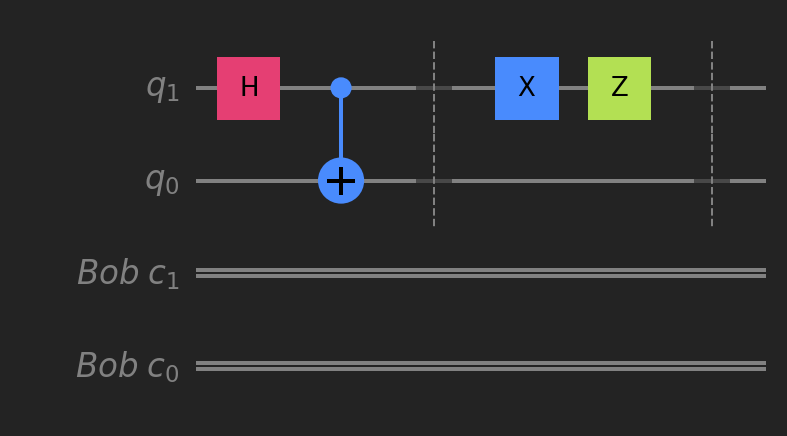

<IPython.core.display.Latex object>

In [33]:
# Alice selects qubits to encode (picked at random for demo purposes)
alice_bits = np.random.randint(2,size=2)

qr = QuantumRegister(2,name="q")
cr = ClassicalRegister(2, name="Bob c")

qc = QuantumCircuit(qr,cr)

# Alice and Bob share entangled Bell state
qc.h(qr[1])
qc.cx(qr[1],qr[0])
qc.barrier()

# Alice encodes classical bits on her qubit
if alice_bits[1] == 1: qc.x(1)
if alice_bits[0] == 1: qc.z(1)
qc.barrier()

# Bob changes from Bell to Computational basis
#qc.cx(qr[1],qr[0])
#qc.h(qr[1])
#qc.barrier()

# Alice measures her qubits
display(qc.draw(cregbundle=False))
Statevector(qc)